In [1]:
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
## Setting up image viewer to look at the data 
# Define our imshow function 
def imshow(title = "Image", image = None, size = 2):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [2]:
train_image_path= 'final_symbols_split_ttv/train'
test_image_path = 'final_symbols_split_ttv/test'
validation_image_path = 'final_symbols_split_ttv/val'

In [3]:
image_test = cv2.imread(train_image_path+'/two/two_6.png')
image_test = cv2.cvtColor(image_test,cv2.COLOR_BGR2GRAY)

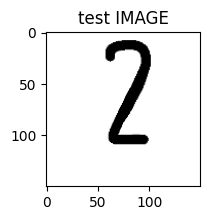

In [4]:
imshow("test IMAGE",image_test,2)

In [5]:
image_test.shape

(150, 150)

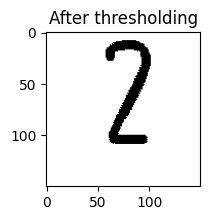

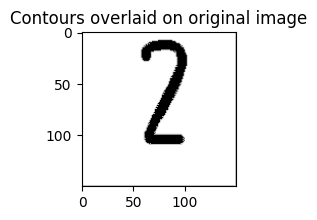

In [6]:
_, th2 = cv2.threshold(image_test, 0, 255, cv2.THRESH_BINARY + cv2.ACCESS_FAST)
imshow('After thresholding', th2,2)

# Finding Contours
# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(image_test, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image_test, contours, -1, (200,0,0), thickness = 1)
imshow('Contours overlaid on original image', image_test,2)

In [4]:
train_datagen = ImageDataGenerator(rescale=1.0/255,
                                  rotation_range=15,
                                  zoom_range=0.2,
                                  width_shift_range=0.3,
                                  height_shift_range=0.3)
train_generator = train_datagen.flow_from_directory(
    train_image_path,              # Path to the root folder
    target_size=(150, 150), # Resize images to this size
    batch_size=16,
    class_mode='categorical'  # or 'binary', 'sparse', 'input', or None
)

Found 42749 images belonging to 14 classes.


In [8]:
print(train_generator.class_indices)

{'add': 0, 'divide': 1, 'eight': 2, 'five': 3, 'four': 4, 'multiply': 5, 'nine': 6, 'one': 7, 'seven': 8, 'six': 9, 'subtract': 10, 'three': 11, 'two': 12, 'zero': 13}


In [5]:
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(test_image_path,              # Path to the root folder
    target_size=(150, 150), # Resize images to this size
    batch_size=16,
    class_mode='categorical'  # or 'binary', 'sparse', 'input', or None
)

Found 5356 images belonging to 14 classes.


In [6]:
validation_datagen = ImageDataGenerator(rescale=1.0/255)
val_generator=validation_datagen.flow_from_directory(
    validation_image_path,
    target_size=(150, 150),
    batch_size=16,
    class_mode='categorical'
)

Found 5337 images belonging to 14 classes.


In [11]:
type(val_generator[0])

tuple

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow.keras.optimizers as optimizers

from tensorflow.keras.callbacks import Callback
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  details = tf.config.experimental.get_device_details(gpus[0])
  print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU details:  {'device_name': 'METAL'}


In [16]:
model = Sequential([
    Conv2D(64, (7, 7), activation='relu', input_shape=(150, 150,3)),
    Conv2D(32, (5, 5), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14, activation='softmax')
])
initial_weights = model.get_weights()


class GeneratorMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_generator):
        super().__init__()
        self.val_generator = val_generator
        self.history = {
            'accuracy': [],
            'val_accuracy': [],
            'val_precision': [],
            'val_recall': []
        }

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Save accuracy from logs
        self.history['accuracy'].append(logs.get('accuracy'))
        self.history['val_accuracy'].append(logs.get('val_accuracy'))

        # Reset generator
        self.val_generator.reset()
        y_pred = []
        y_true = []

        # Predict entire validation set
        for i in range(len(self.val_generator)):
            x_batch, y_batch = self.val_generator[i]
            preds = self.model.predict(x_batch, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(np.argmax(y_batch, axis=1))

        # Compute metrics
        precision = tf.keras.metrics.Precision()
        recall = tf.keras.metrics.Recall()

        precision.update_state(y_true, y_pred)
        recall.update_state(y_true, y_pred)

        self.history['val_precision'].append(precision.result().numpy())
        self.history['val_recall'].append(recall.result().numpy())
        
# Plotting function
def plot_metrics(history):
    epochs = range(1, len(history['accuracy']) + 1)
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['accuracy'], label='Train Acc')
    plt.plot(epochs, history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['precision'], label='Train Precision')
    plt.plot(epochs, history['val_precision'], label='Val Precision')
    plt.title('Precision')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['recall'], label='Train Recall')
    plt.plot(epochs, history['val_recall'], label='Val Recall')
    plt.title('Recall')
    plt.legend()

    plt.tight_layout()
    plt.show()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Save initial weights
initial_weights = model.get_weights()


# lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.25,        # reduce by 1/4
#     patience=1,        # after 1 epochs with no improvement
#     verbose=1,
#     min_lr=1e-8
# )


/opt/anaconda3/envs/Learning_enviroment/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model = Sequential([
    Conv2D(64, (7, 7),2, activation='relu', input_shape=(150, 150,3)),
    Conv2D(32, (5, 5), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14, activation='softmax')
])

In [22]:
model.compile(optimizer=optimizers.Adagrad(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])



In [23]:

# Train
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6
)


Epoch 1/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 74s 28ms/step - accuracy: 0.1548 - loss: 2.5124 - val_accuracy: 0.5186 - val_loss: 1.4873
Epoch 2/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.3841 - loss: 2.1187 - val_accuracy: 0.3903 - val_loss: 5.2162
Epoch 3/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.3236 - loss: 10.8972 - val_accuracy: 0.3556 - val_loss: 25.9201
Epoch 4/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.3246 - loss: 39.2056 - val_accuracy: 0.3905 - val_loss: 44.5128
Epoch 5/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.3416 - loss: 70.7821 - val_accuracy: 0.4875 - val_loss: 57.1326
Epoch 6/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 71s 27ms/step - accuracy: 0.3553 - loss: 100.0266 - val_accuracy: 0.4034 - val_loss: 100.4956


In [26]:
def plot_metrics(history):
    epochs = range(1, len(history['accuracy']) + 1)

    plt.figure(figsize=(16, 5))

    # Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['accuracy'], 'b', label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], 'r', label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Precision
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_precision'], 'g', label='Val Precision')
    plt.title('Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.legend()

    # Recall
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['val_recall'], 'm', label='Val Recall')
    plt.title('Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [25]:
model2 = Sequential([
    Conv2D(64, (7, 7),2, activation='relu', input_shape=(150, 150,3)),
    Conv2D(32, (5, 5),2, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14, activation='softmax')
])

model2.compile(optimizer=optimizers.Adagrad(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6
)

Epoch 1/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 74s 28ms/step - accuracy: 0.1193 - loss: 2.5902 - val_accuracy: 0.3965 - val_loss: 1.9693
Epoch 2/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.3360 - loss: 2.0697 - val_accuracy: 0.5276 - val_loss: 1.4293
Epoch 3/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.3834 - loss: 2.1979 - val_accuracy: 0.3656 - val_loss: 5.0780
Epoch 4/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.3179 - loss: 7.0397 - val_accuracy: 0.3135 - val_loss: 16.5665
Epoch 5/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.2896 - loss: 22.4527 - val_accuracy: 0.2779 - val_loss: 30.5158
Epoch 6/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.2731 - loss: 46.5166 - val_accuracy: 0.3952 - val_loss: 33.6380


In [26]:
model3 = Sequential([
    Conv2D(64, (7, 7),5, activation='relu', input_shape=(150, 150,3)),
    Conv2D(32, (5, 5),3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14, activation='softmax')
])

model3.compile(optimizer=optimizers.Adagrad(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6
)

Epoch 1/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.1117 - loss: 2.6246 - val_accuracy: 0.1555 - val_loss: 2.5091
Epoch 2/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.1846 - loss: 2.4824 - val_accuracy: 0.3225 - val_loss: 2.0690
Epoch 3/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.2842 - loss: 2.1897 - val_accuracy: 0.4446 - val_loss: 1.6797
Epoch 4/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 71s 27ms/step - accuracy: 0.3387 - loss: 2.0076 - val_accuracy: 0.4928 - val_loss: 1.4999
Epoch 5/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 71s 27ms/step - accuracy: 0.3852 - loss: 1.9121 - val_accuracy: 0.5497 - val_loss: 1.3481
Epoch 6/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 71s 26ms/step - accuracy: 0.4092 - loss: 1.8775 - val_accuracy: 0.5496 - val_loss: 1.3724


In [30]:
model4 = Sequential([
    Conv2D(64, (11, 11),3, activation='relu', input_shape=(150, 150,3)),
    Conv2D(32, (7, 7),5, activation='relu'),
    Conv2D(16,(3,3),activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14, activation='softmax')
])

model4.compile(optimizer=optimizers.Adagrad(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model4.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6
)

Epoch 1/6


/opt/anaconda3/envs/Learning_enviroment/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.1049 - loss: 2.6205 - val_accuracy: 0.2762 - val_loss: 2.3028
Epoch 2/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.2317 - loss: 2.3540 - val_accuracy: 0.4399 - val_loss: 1.6355
Epoch 3/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step - accuracy: 0.3287 - loss: 2.0644 - val_accuracy: 0.4881 - val_loss: 1.5502
Epoch 4/6
2595/2672 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3609 - loss: 2.3264  

KeyboardInterrupt: 

In [31]:
model3 = Sequential([
    Conv2D(64, (7, 7),5, activation='relu', input_shape=(150, 150,3)),
    Conv2D(32, (5, 5),3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(14, activation='softmax')
])

model3.compile(optimizer=optimizers.Adagrad(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12
)

Epoch 1/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.0936 - loss: 2.6303 - val_accuracy: 0.2054 - val_loss: 2.5168
Epoch 2/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.1725 - loss: 2.5282 - val_accuracy: 0.3483 - val_loss: 2.1155
Epoch 3/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 71s 27ms/step - accuracy: 0.2813 - loss: 2.2476 - val_accuracy: 0.4467 - val_loss: 1.7365
Epoch 4/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.3506 - loss: 1.9983 - val_accuracy: 0.4984 - val_loss: 1.5080
Epoch 5/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.4050 - loss: 1.8527 - val_accuracy: 0.5511 - val_loss: 1.3723
Epoch 6/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.4381 - loss: 1.7777 - val_accuracy: 0.5927 - val_loss: 1.2609
Epoch 7/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.4577 - loss: 1.7569 - val_accuracy: 0.6016 - val_loss: 1.2103
Epoch 8/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 72s 27ms/step - accuracy: 0.4662 -

In [45]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, Add, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def residual_block(x, filters, downsample=False):
    shortcut = x
    strides = 2 if downsample else 1

    # First conv layer
    x = Conv2D(filters, (3, 3), strides=strides, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Second conv layer
    x = Conv2D(filters, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Adjust shortcut to match shape
    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add skip connection
    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_resnet(input_shape=(150, 150, 3), num_classes=14):
    inputs = Input(shape=input_shape)

    # Initial convolution
    x = Conv2D(64, (7, 7), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Residual blocks
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    # Global average pooling & classification
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


In [46]:
resnet_model = build_resnet()

In [47]:
resnet_model = build_resnet()
resnet_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
resnet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 75, 75,    │      9,472 │ input_layer_15[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 75, 75,    │     36,928 │ re_lu_11[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 75, 75,    │     36,928 │ re_lu_12[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 75, 75,    │          0 │ add_4[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 75, 75,    │     36,928 │ re_lu_13[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 75, 75,    │     36,928 │ re_lu_14[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 75, 75,    │          0 │ batch_normalizat

 Total params: 704,270 (2.69 MB)

 Trainable params: 702,350 (2.68 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [48]:
resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6
)

Epoch 1/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 212s 78ms/step - accuracy: 0.4690 - loss: 1.6099 - val_accuracy: 0.5271 - val_loss: 2.2839
Epoch 2/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 207s 78ms/step - accuracy: 0.8344 - loss: 0.5307 - val_accuracy: 0.6985 - val_loss: 1.0846
Epoch 3/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 207s 77ms/step - accuracy: 0.8931 - loss: 0.3408 - val_accuracy: 0.4218 - val_loss: 6.8200
Epoch 4/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 207s 78ms/step - accuracy: 0.9183 - loss: 0.2607 - val_accuracy: 0.2942 - val_loss: 19.3481
Epoch 5/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 1137s 426ms/step - accuracy: 0.9273 - loss: 0.2264 - val_accuracy: 0.5068 - val_loss: 3.3072
Epoch 6/6
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 209s 78ms/step - accuracy: 0.9361 - loss: 0.2073 - val_accuracy: 0.1909 - val_loss: 19.9170
